# OCT - EfficientNet-B3 Advanced | 3 Sinif | Final Colab

Bu notebook EfficientNet-B3 ile OCT 3 sinif final deneyi icin hazirlandi.

Temel akış:

- Google Drive mount
- Drive verisini Colab local cache'e kopyalama
- CNV dislama, `NORMAL / DR / AMD` siniflariyla calisma
- Mevcut `split_3sinif.json` ile hasta bazli train/val/test ayrimi
- EfficientNet-B3 ImageNet pretrained backbone
- Retina band crop, WeightedRandomSampler, Focal Loss + CrossEntropy
- MixUp, EMA ve validation threshold aramasi
- Image-level ve patient-level rapor, confusion matrix, CSV ve TXT ciktilar

Beklenen Drive yapisi:

```text
MyDrive/bitirme/data/OCT
MyDrive/bitirme/data/Textlabels.xlsx
MyDrive/bitirme/data/split_3sinif.json
```

Sonuclar `MyDrive/bitirme/outputs/efficientnet_b3_advanced_oct_3sinif_colab` altina kaydedilir.


In [14]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip -q install openpyxl scikit-learn seaborn tqdm

import os, json, random, shutil, platform, re, math, copy, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageFile
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from torchvision import transforms, models

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    roc_auc_score,
)

ImageFile.LOAD_TRUNCATED_IMAGES = True
warnings.filterwarnings('default')

def clean_patient_id(x):
    if pd.isna(x):
        return None
    if isinstance(x, float) and x.is_integer():
        return str(int(x))
    s = str(x).strip()
    if s.endswith('.0') and s[:-2].isdigit():
        s = s[:-2]
    return s

def norm_label(x):
    return str(x).strip().upper()

def natural_key(path):
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r'(\d+)', str(path))]

def find_col(columns, candidates):
    lower_map = {str(c).strip().lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    raise ValueError(f'Kolon bulunamadi. Mevcut kolonlar: {list(columns)}')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def safe_auc_ovr(y_true, probs, verbose=False):
    try:
        return roc_auc_score(y_true, probs, multi_class='ovr', average='macro')
    except Exception as e:
        if verbose:
            print('AUC hesaplanamadi:', repr(e))
        return np.nan

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=1.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        if self.alpha is not None:
            loss = loss * self.alpha[targets]
        return loss.mean()

def predict_with_thresholds(probs, dr_thr, amd_thr):
    preds = []
    eps = 1e-8
    for p in probs:
        candidates = []
        if p[1] >= dr_thr:
            candidates.append((p[1] / max(dr_thr, eps), 1))
        if p[2] >= amd_thr:
            candidates.append((p[2] / max(amd_thr, eps), 2))
        preds.append(max(candidates)[1] if candidates else 0)
    return np.array(preds)

def score_thresholds(y_true, pred):
    macro_f1 = f1_score(y_true, pred, average='macro', zero_division=0)
    bal_acc = balanced_accuracy_score(y_true, pred)
    dr_rec = recall_score(y_true, pred, labels=[1], average='macro', zero_division=0)
    dr_prec = precision_score(y_true, pred, labels=[1], average='macro', zero_division=0)
    amd_rec = recall_score(y_true, pred, labels=[2], average='macro', zero_division=0)
    return {
        'macro_f1': float(macro_f1),
        'balanced_acc': float(bal_acc),
        'dr_recall': float(dr_rec),
        'dr_precision': float(dr_prec),
        'amd_recall': float(amd_rec),
        'score': float(0.35 * macro_f1 + 0.30 * bal_acc + 0.20 * dr_rec + 0.10 * dr_prec + 0.05 * amd_rec),
    }

def search_thresholds(y_true, probs):
    best = None
    for dr_thr in np.linspace(0.15, 0.70, 23):
        for amd_thr in np.linspace(0.15, 0.70, 23):
            pred = predict_with_thresholds(probs, dr_thr, amd_thr)
            item = {'dr_thr': float(dr_thr), 'amd_thr': float(amd_thr)}
            item.update(score_thresholds(y_true, pred))
            if best is None or item['score'] > best['score']:
                best = item
    return best

def patient_aggregate(frame, mode='mean'):
    rows = []
    for pid, g in frame.groupby('patient_id'):
        true = int(g['true'].iloc[0])
        probs = g[['p_normal', 'p_dr', 'p_amd']].values
        k20 = min(20, len(g))
        k40 = min(40, len(g))
        if mode == 'mean':
            score = probs.mean(axis=0)
        elif mode == 'top20':
            score = np.array([probs[:, 0].mean(), np.sort(probs[:, 1])[-k20:].mean(), np.sort(probs[:, 2])[-k20:].mean()])
        elif mode == 'top40':
            score = np.array([probs[:, 0].mean(), np.sort(probs[:, 1])[-k40:].mean(), np.sort(probs[:, 2])[-k40:].mean()])
        elif mode == 'mean_top20_mix':
            top = np.array([probs[:, 0].mean(), np.sort(probs[:, 1])[-k20:].mean(), np.sort(probs[:, 2])[-k20:].mean()])
            score = 0.60 * probs.mean(axis=0) + 0.40 * top
        else:
            raise ValueError(mode)
        rows.append({
            'patient_id': pid,
            'true': true,
            'true_name': IDX_TO_CLASS[true],
            'p_normal': score[0],
            'p_dr': score[1],
            'p_amd': score[2],
            'mode': mode,
            'n_images': len(g),
        })
    return pd.DataFrame(rows)

print('Importlar ve helper fonksiyonlar tamam.')


Importlar ve helper fonksiyonlar tamam.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [3]:
print('Platform:', platform.platform())
print('CUDA:', torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError('GPU aktif degil. Colab > Runtime > Change runtime type > GPU sec.')

print('GPU:', torch.cuda.get_device_name(0))
!nvidia-smi

torch.backends.cudnn.benchmark = True

CLASS_NAMES = ['NORMAL', 'DR', 'AMD']
CLASS_TO_IDX = {'NORMAL': 0, 'DR': 1, 'AMD': 2}
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}

SEED = 42
IMG_SIZE = 300
BATCH_SIZE = 16
NUM_EPOCHS = 35
PATIENCE = 10
FREEZE_EPOCHS = 1
MAX_LR = 3e-4
BACKBONE_LR_RATIO = 0.15
WEIGHT_DECAY = 1.5e-4
NUM_WORKERS = 0  # Colab multiprocessing uyarilarini engellemek icin 0

USE_MIXUP = True
MIXUP_PROB = 0.20
MIXUP_ALPHA = 0.15

USE_EMA = True
EMA_DECAY = 0.995
set_seed(SEED)
device = torch.device('cuda')

DRIVE_BASE = Path('/content/drive/MyDrive/bitirme')
DRIVE_DATA = DRIVE_BASE / 'data'
DRIVE_OCT = DRIVE_DATA / 'OCT'
DRIVE_EXCEL = DRIVE_DATA / 'Textlabels.xlsx'
SPLIT_PATH = DRIVE_DATA / 'split_3sinif.json'

SAVE_DIR = DRIVE_BASE / 'outputs' / 'efficientnet_b3_advanced_oct_3sinif_colab'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

LOCAL_BASE = Path('/content/bitirme_cache_oct_effb3_3class')
LOCAL_DATA = LOCAL_BASE / 'data'
LOCAL_OCT = LOCAL_DATA / 'OCT'
LOCAL_EXCEL = LOCAL_DATA / 'Textlabels.xlsx'

assert DRIVE_OCT.exists(), DRIVE_OCT
assert DRIVE_EXCEL.exists(), DRIVE_EXCEL
assert SPLIT_PATH.exists(), SPLIT_PATH

print('Split:', SPLIT_PATH)
print('Output:', SAVE_DIR)


Platform: Linux-6.6.122+-x86_64-with-glibc2.35
CUDA: True
GPU: Tesla T4
Fri Jun  5 11:38:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8             14W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |

In [4]:
LOCAL_DATA.mkdir(parents=True, exist_ok=True)
LOCAL_OCT.mkdir(parents=True, exist_ok=True)

shutil.copy2(DRIVE_EXCEL, LOCAL_EXCEL)

df_raw = pd.read_excel(LOCAL_EXCEL)
df_raw.columns = df_raw.columns.str.strip()

id_col = find_col(df_raw.columns, ['ID', 'Patient ID', 'patient_id'])
disease_col = find_col(df_raw.columns, ['Disease', 'disease', 'Diagnosis', 'Class', 'Label'])

df = df_raw[[id_col, disease_col]].copy()
df.columns = ['patient_id', 'disease']
df['patient_id'] = df['patient_id'].map(clean_patient_id)
df['disease'] = df['disease'].map(norm_label)

df = df[df['disease'].isin(CLASS_NAMES)].dropna().drop_duplicates('patient_id').reset_index(drop=True)
df['label'] = df['disease'].map(CLASS_TO_IDX).astype(int)

print('Hasta bazli dagilim:')
print(df['disease'].value_counts())

FORCE_RECOPY = False
copied, skipped, missing = 0, 0, []
flat_files_used = []
copy_errors = []

print('Drive OCT icerik ornegi:')
for item in list(DRIVE_OCT.iterdir())[:12]:
    print(' ', item.name, 'DIR' if item.is_dir() else 'FILE')

for pid in tqdm(sorted(df['patient_id'].unique()), desc='Drive -> local cache'):
    src = DRIVE_OCT / pid
    dst = LOCAL_OCT / pid

    # Beklenen format: data/OCT/10303/1.bmp ...
    if src.exists() and src.is_dir():
        try:
            src_count = len(list(src.glob('*.bmp')))
            dst_count = len(list(dst.glob('*.bmp'))) if dst.exists() else -1
            if FORCE_RECOPY or (not dst.exists()) or (src_count != dst_count):
                if dst.exists():
                    shutil.rmtree(dst)
                shutil.copytree(src, dst)
                copied += 1
            else:
                skipped += 1
        except FileNotFoundError as e:
            # Google Drive bazen exists() true donup copy aninda klasoru gecici olarak kaybedebiliyor.
            copy_errors.append((pid, repr(e)))
            missing.append(pid)
        continue

    # Alternatif format: data/OCT/10303.bmp gibi tek dosya.
    flat_candidates = []
    for ext in ['.bmp', '.png', '.jpg', '.jpeg', '.tif', '.tiff']:
        flat_candidates.extend(DRIVE_OCT.glob(f'{pid}{ext}'))
    if flat_candidates:
        dst.mkdir(parents=True, exist_ok=True)
        for src_file in flat_candidates:
            dst_file = dst / src_file.name
            if FORCE_RECOPY or (not dst_file.exists()) or (src_file.stat().st_size != dst_file.stat().st_size):
                shutil.copy2(src_file, dst_file)
        flat_files_used.append(pid)
        copied += 1
        continue

    missing.append(pid)

if flat_files_used:
    print(
        f'Uyari: {len(flat_files_used)} hasta klasor yerine tek dosya formatindan okundu. '
        'Bu format hasta basina coklu OCT kesitleri yerine tek goruntu kullanir.'
    )

if copy_errors:
    print(f'Uyari: Google Drive kopyalama sirasinda gecici/erisilebilirlik hatasi sayisi: {len(copy_errors)}')
    print('Ornek:', copy_errors[:5])

if missing:
    print(f'Uyari: Drive OCT icinde eksik/okunamayan hasta verisi sayisi: {len(missing)} | Ornek: {missing[:10]}')

if len(missing) == df['patient_id'].nunique():
    raise RuntimeError(
        'OCT verisi bulunamadi. Beklenen yapi: MyDrive/bitirme/data/OCT/10303/*.bmp. '
        'Alternatif olarak MyDrive/bitirme/data/OCT/10303.bmp de desteklenir. '
        'Drive OCT klasorunun dogru yerde oldugunu ve icinde hasta ID klasorleri oldugunu kontrol et.'
    )

rows = []
for _, r in tqdm(df.iterrows(), total=len(df), desc='Goruntu listesi'):
    pid = r['patient_id']
    files = sorted((LOCAL_OCT / pid).glob('*.bmp'), key=natural_key)
    for f in files:
        rows.append({'patient_id': pid, 'path': str(f), 'disease': r['disease'], 'label': int(r['label'])})

img_df = pd.DataFrame(rows)

print('\nGoruntu bazli dagilim:')
print(img_df['disease'].value_counts())

patient_counts = img_df.groupby('patient_id').size()
expected_patients = df['patient_id'].nunique() - len(missing)
assert img_df['patient_id'].nunique() == expected_patients
assert len(img_df) > 0
assert patient_counts.min() > 0

print('Veri butunluk kontrolu tamam.')
print('Beklenen hasta:', expected_patients, '| Bulunan hasta:', img_df['patient_id'].nunique(), '| Goruntu:', len(img_df))
print('Kopyalanan:', copied, 'Atlanan:', skipped)


Hasta bazli dagilim:
disease
NORMAL    160
DR         29
AMD         6
Name: count, dtype: int64
Drive OCT icerik ornegi:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  10497 DIR
  10498 DIR
  10499 DIR
  10496 DIR
  10493 DIR
  10494 DIR
  10495 DIR
  10489 DIR
  10488 DIR
  10492 DIR
  10491 DIR
  10490 DIR


Drive -> local cache:   0%|          | 0/195 [00:00<?, ?it/s]

Uyari: Drive OCT icinde eksik/okunamayan hasta verisi sayisi: 2 | Ornek: ['10400', '10500']


Goruntu listesi:   0%|          | 0/195 [00:00<?, ?it/s]


Goruntu bazli dagilim:
disease
NORMAL    47939
DR         8788
AMD        1824
Name: count, dtype: int64
Veri butunluk kontrolu tamam.
Beklenen hasta: 193 | Bulunan hasta: 193 | Goruntu: 58551
Kopyalanan: 193 Atlanan: 0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [5]:
with open(SPLIT_PATH, 'r', encoding='utf-8') as f:
    split = json.load(f)

train_ids = set(map(clean_patient_id, split['train']))
val_ids = set(map(clean_patient_id, split['val']))
test_ids = set(map(clean_patient_id, split['test']))

assert len(train_ids & val_ids) == 0
assert len(train_ids & test_ids) == 0
assert len(val_ids & test_ids) == 0
assert train_ids | val_ids | test_ids == set(df['patient_id'])

train_df = img_df[img_df['patient_id'].isin(train_ids)].reset_index(drop=True)
val_df = img_df[img_df['patient_id'].isin(val_ids)].reset_index(drop=True)
test_df = img_df[img_df['patient_id'].isin(test_ids)].reset_index(drop=True)

def show_split(name, part):
    print(f'\n{name}')
    print('Hasta:', part['patient_id'].nunique())
    print('Goruntu:', len(part))
    print('Hasta dagilimi:')
    print(part.drop_duplicates('patient_id')['disease'].value_counts().reindex(CLASS_NAMES, fill_value=0))
    print('Goruntu dagilimi:')
    print(part['disease'].value_counts().reindex(CLASS_NAMES, fill_value=0))

show_split('TRAIN', train_df)
show_split('VAL', val_df)
show_split('TEST', test_df)

for name, part in [('train', train_df), ('val', val_df), ('test', test_df)]:
    assert set(part['label'].unique()) == {0, 1, 2}, f'{name} splitinde sinif eksik.'

print('\nAyni split_3sinif.json kullaniliyor.')



TRAIN
Hasta: 131
Goruntu: 39703
Hasta dagilimi:
disease
NORMAL    107
DR         20
AMD         4
Name: count, dtype: int64
Goruntu dagilimi:
disease
NORMAL    32435
DR         6052
AMD        1216
Name: count, dtype: int64

VAL
Hasta: 24
Goruntu: 7296
Hasta dagilimi:
disease
NORMAL    20
DR         3
AMD        1
Name: count, dtype: int64
Goruntu dagilimi:
disease
NORMAL    6080
DR         912
AMD        304
Name: count, dtype: int64

TEST
Hasta: 38
Goruntu: 11552
Hasta dagilimi:
disease
NORMAL    31
DR         6
AMD        1
Name: count, dtype: int64
Goruntu dagilimi:
disease
NORMAL    9424
DR        1824
AMD        304
Name: count, dtype: int64

Ayni split_3sinif.json kullaniliyor.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [6]:
def crop_to_retina_band(pil_img, threshold=12, margin=28):
    arr = np.array(pil_img)
    gray = arr.mean(axis=2) if arr.ndim == 3 else arr
    row_strength = gray.mean(axis=1)
    rows = np.where(row_strength > threshold)[0]
    if len(rows) == 0:
        return pil_img
    top = max(0, int(rows[0]) - margin)
    bottom = min(arr.shape[0], int(rows[-1]) + margin)
    crop = arr[top:bottom, :]
    return Image.fromarray(crop.astype(np.uint8))

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.Lambda(crop_to_retina_band),
    transforms.Resize((IMG_SIZE + 28, IMG_SIZE + 28)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=4, translate=(0.035, 0.035), scale=(0.95, 1.06)),
    transforms.RandomApply([transforms.ColorJitter(brightness=0.12, contrast=0.20)], p=0.45),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
    transforms.RandomErasing(p=0.10, scale=(0.01, 0.04), ratio=(0.4, 2.5), value='random'),
])

eval_tfms = transforms.Compose([
    transforms.Lambda(crop_to_retina_band),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

class OCTDataset(Dataset):
    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform
        self.by_label = {
            int(label): group.index.to_list()
            for label, group in self.frame.groupby('label')
        }

    def __len__(self):
        return len(self.frame)

    def _open_image(self, path):
        with Image.open(path) as img:
            img.load()
            return img.convert('RGB')

    def __getitem__(self, idx):
        r = self.frame.iloc[idx]
        try:
            img = self._open_image(r['path'])
        except Exception as exc:
            # Colab/Drive tarafinda nadiren bozuk veya eksik kopyalanmis bmp okunabiliyor.
            # Egitimi durdurmamak icin ayni siniftan deterministik bir yedek ornek kullanilir.
            label = int(r['label'])
            candidates = self.by_label.get(label, [])
            if not candidates:
                raise exc
            fallback_idx = candidates[(idx + 1) % len(candidates)]
            r = self.frame.iloc[fallback_idx]
            img = self._open_image(r['path'])
        img = self.transform(img)
        return img, int(r['label']), r['path'], r['patient_id']

train_dataset = OCTDataset(train_df, train_tfms)
val_dataset = OCTDataset(val_df, eval_tfms)
test_dataset = OCTDataset(test_df, eval_tfms)

label_counts = train_df['label'].value_counts().reindex([0, 1, 2], fill_value=0).astype(float).values
raw_weights = len(train_df) / (len(CLASS_NAMES) * label_counts)

# Orijinal notebook'ta loss ve sampler ayni anda cok agresifti. Burada denge korunuyor ama uc sinif asiri sisirilmiyor.
loss_weights = np.sqrt(raw_weights)
loss_weights = loss_weights / loss_weights.mean()
loss_weights[1] *= 1.20
loss_weights[2] *= 1.35
loss_weights = np.clip(loss_weights, 0.45, 4.00)

sampler_weights = np.sqrt(raw_weights)
sampler_weights[1] *= 1.15
sampler_weights[2] *= 1.25
sample_weights = train_df['label'].map(lambda y: sampler_weights[int(y)]).values

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True,
)

pin = device.type == 'cuda'
persistent = NUM_WORKERS > 0

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS, pin_memory=pin, persistent_workers=persistent)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin, persistent_workers=persistent)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin, persistent_workers=persistent)

class_weights_t = torch.tensor(loss_weights, dtype=torch.float32, device=device)

print('Train label counts:', label_counts)
print('Raw inverse weights:', raw_weights)
for name, lw, sw in zip(CLASS_NAMES, loss_weights, sampler_weights):
    print(f'{name}: loss_weight={lw:.3f} sampler_weight={sw:.3f}')


Train label counts: [32435.  6052.  1216.]
Raw inverse weights: [ 0.40802631  2.18677021 10.88349781]
NORMAL: loss_weight=0.450 sampler_weight=0.639
DR: loss_weight=0.983 sampler_weight=1.701
AMD: loss_weight=2.467 sampler_weight=4.124


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [7]:
weights = models.EfficientNet_B3_Weights.DEFAULT
model = models.efficientnet_b3(weights=weights)

in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.40),
    nn.Linear(in_features, 256),
    nn.SiLU(inplace=True),
    nn.BatchNorm1d(256),
    nn.Dropout(0.25),
    nn.Linear(256, len(CLASS_NAMES)),
)

for p in model.features.parameters():
    p.requires_grad = False

model = model.to(device)
ema_model = copy.deepcopy(model).eval().to(device) if USE_EMA else None
if ema_model is not None:
    for p in ema_model.parameters():
        p.requires_grad = False

backbone_params = list(model.features.parameters())
head_params = list(model.classifier.parameters())

optimizer = torch.optim.AdamW(
    [
        {'params': backbone_params, 'lr': MAX_LR * BACKBONE_LR_RATIO, 'weight_decay': WEIGHT_DECAY},
        {'params': head_params, 'lr': MAX_LR, 'weight_decay': WEIGHT_DECAY},
    ]
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=[MAX_LR * BACKBONE_LR_RATIO, MAX_LR],
    epochs=NUM_EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.18,
    div_factor=8.0,
    final_div_factor=80.0,
)

focal_loss = FocalLoss(alpha=class_weights_t, gamma=1.5)
ce_loss = nn.CrossEntropyLoss(weight=class_weights_t, label_smoothing=0.03)

def combined_loss(logits, labels):
    return 0.55 * focal_loss(logits, labels) + 0.45 * ce_loss(logits, labels)

def mixup_data(x, y, alpha):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

@torch.no_grad()
def update_ema(model, ema_model, decay):
    if ema_model is None:
        return
    msd = model.state_dict()
    for k, ema_v in ema_model.state_dict().items():
        model_v = msd[k].detach()
        if torch.is_floating_point(ema_v):
            ema_v.mul_(decay).add_(model_v, alpha=1.0 - decay)
        else:
            ema_v.copy_(model_v)

scaler = GradScaler(enabled=True)

CHECKPOINT = SAVE_DIR / 'efficientnet_b3_advanced_best_macrof1_patient.pt'
HISTORY_PATH = SAVE_DIR / 'history_effb3_advanced.csv'
THRESHOLD_PATH = SAVE_DIR / 'best_thresholds_effb3_advanced.json'

print('EfficientNet-B3 advanced final hazir.')
print('Checkpoint:', CHECKPOINT)


Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 197MB/s]


EfficientNet-B3 advanced final hazir.
Checkpoint: /content/drive/MyDrive/bitirme/outputs/efficientnet_b3_advanced_oct_3sinif_colab/efficientnet_b3_advanced_best_macrof1_patient.pt


/tmp/ipykernel_440/2127489116.py:69: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=True)


In [8]:
def train_one_epoch(epoch):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0
    for images, labels, _, _ in tqdm(train_loader, desc=f'Epoch {epoch} train', leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        use_mixup = USE_MIXUP and (np.random.rand() < MIXUP_PROB)
        with autocast(enabled=True):
            if use_mixup:
                images_m, y_a, y_b, lam = mixup_data(images, labels, MIXUP_ALPHA)
                logits = model(images_m)
                loss = mixup_criterion(combined_loss, logits, y_a, y_b, lam)
            else:
                logits = model(images)
                loss = combined_loss(logits, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        update_ema(model, ema_model, EMA_DECAY)
        bs = labels.size(0)
        total_loss += loss.item() * bs
        total_correct += (logits.argmax(1) == labels).sum().item()
        total_seen += bs
    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def predict_loader(loader, desc, eval_model=None):
    eval_model = eval_model if eval_model is not None else model
    eval_model.eval()
    total_loss, total_seen = 0.0, 0
    all_probs, all_labels, all_paths, all_pids = [], [], [], []
    for images, labels, paths, pids in tqdm(loader, desc=desc, leave=False):
        images = images.to(device, non_blocking=True)
        labels_gpu = labels.to(device, non_blocking=True)
        with autocast(enabled=True):
            logits = eval_model(images)
            loss = combined_loss(logits, labels_gpu)
        probs = torch.softmax(logits, dim=1).detach().cpu().numpy()
        bs = labels.size(0)
        total_loss += loss.item() * bs
        total_seen += bs
        all_probs.append(probs)
        all_labels.extend(labels.numpy().tolist())
        all_paths.extend(list(paths))
        all_pids.extend(list(pids))
    return total_loss / total_seen, np.concatenate(all_probs, axis=0), np.array(all_labels), all_paths, all_pids

def build_prediction_frame(probs, y, paths, pids):
    frame = pd.DataFrame({
        'patient_id': pids,
        'path': paths,
        'true': y,
        'true_name': [IDX_TO_CLASS[int(x)] for x in y],
        'p_normal': probs[:, 0],
        'p_dr': probs[:, 1],
        'p_amd': probs[:, 2],
    })
    return frame

def search_best_patient_config(frame):
    best = None
    for mode in ['mean', 'top20', 'top40', 'mean_top20_mix']:
        patient = patient_aggregate(frame, mode)
        probs_patient = patient[['p_normal', 'p_dr', 'p_amd']].values
        y_patient = patient['true'].values
        info = search_thresholds(y_patient, probs_patient)
        info['mode'] = mode
        if best is None or info['score'] > best['score']:
            best = info
    return best

history = []
best_score = -1
patience_counter = 0

print('EGITIM BASLIYOR')
print('Epoch | TrLoss | TrAcc | ValLoss | ImgF1 | ImgBal | PatF1 | PatBal | DRRec | Mode | Score')
print('-' * 112)

for epoch in range(1, NUM_EPOCHS + 1):
    if epoch == FREEZE_EPOCHS + 1:
        for p in model.features.parameters():
            p.requires_grad = True
        print('Backbone acildi, fine-tuning basladi.')

    train_loss, train_acc = train_one_epoch(epoch)
    eval_model = ema_model if ema_model is not None else model
    val_loss, val_probs, val_y, val_paths, val_pids = predict_loader(val_loader, f'Epoch {epoch} val', eval_model=eval_model)

    img_thr = search_thresholds(val_y, val_probs)
    val_pred = predict_with_thresholds(val_probs, img_thr['dr_thr'], img_thr['amd_thr'])
    img_metrics = score_thresholds(val_y, val_pred)

    val_img_df = build_prediction_frame(val_probs, val_y, val_paths, val_pids)
    patient_cfg = search_best_patient_config(val_img_df)
    val_patient = patient_aggregate(val_img_df, patient_cfg['mode'])
    patient_probs = val_patient[['p_normal', 'p_dr', 'p_amd']].values
    patient_pred = predict_with_thresholds(patient_probs, patient_cfg['dr_thr'], patient_cfg['amd_thr'])
    patient_metrics = score_thresholds(val_patient['true'].values, patient_pred)

    # Final model secimi patient-level'i one cikarir ama image-level'i tamamen yok saymaz.
    select_score = 0.65 * patient_metrics['score'] + 0.35 * img_metrics['score']

    row = {
        'epoch': epoch,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'val_loss': val_loss,
        'img_dr_thr': img_thr['dr_thr'],
        'img_amd_thr': img_thr['amd_thr'],
        'img_macro_f1': img_metrics['macro_f1'],
        'img_bal_acc': img_metrics['balanced_acc'],
        'img_dr_recall': img_metrics['dr_recall'],
        'patient_mode': patient_cfg['mode'],
        'patient_dr_thr': patient_cfg['dr_thr'],
        'patient_amd_thr': patient_cfg['amd_thr'],
        'patient_macro_f1': patient_metrics['macro_f1'],
        'patient_bal_acc': patient_metrics['balanced_acc'],
        'patient_dr_recall': patient_metrics['dr_recall'],
        'select_score': select_score,
        'val_auc_ovr': safe_auc_ovr(val_y, val_probs),
    }
    history.append(row)
    pd.DataFrame(history).to_csv(HISTORY_PATH, index=False)

    print(
        f'{epoch:5d} | {train_loss:.4f} | {train_acc*100:5.1f} | {val_loss:.4f} | '
        f'{row["img_macro_f1"]:.4f} | {row["img_bal_acc"]:.4f} | {row["patient_macro_f1"]:.4f} | '
        f'{row["patient_bal_acc"]:.4f} | {row["patient_dr_recall"]:.4f} | {row["patient_mode"]:<14s} | {select_score:.4f}'
    )

    if select_score > best_score:
        best_score = select_score
        patience_counter = 0
        state_model = eval_model if ema_model is not None else model
        torch.save(
            {
                'model_state_dict': state_model.state_dict(),
                'epoch': epoch,
                'image_thresholds': img_thr,
                'patient_thresholds': patient_cfg,
                'class_names': CLASS_NAMES,
                'img_size': IMG_SIZE,
                'use_ema': USE_EMA,
                'select_score': best_score,
            },
            CHECKPOINT,
        )
        with open(THRESHOLD_PATH, 'w', encoding='utf-8') as f:
            json.dump({'image_thresholds': img_thr, 'patient_thresholds': patient_cfg, 'select_score': best_score}, f, indent=2)
        print('  -> En iyi model kaydedildi.')
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print(f'Erken durdurma: {PATIENCE} epoch iyilesme yok.')
        break

print('Egitim tamamlandi. Best select_score:', best_score)


EGITIM BASLIYOR
Epoch | TrLoss | TrAcc | ValLoss | ImgF1 | ImgBal | PatF1 | PatBal | DRRec | Mode | Score
----------------------------------------------------------------------------------------------------------------


Epoch 1 train:   0%|          | 0/2482 [00:00<?, ?it/s]

/tmp/ipykernel_440/1929428434.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):


Epoch 1 val:   0%|          | 0/456 [00:00<?, ?it/s]

/tmp/ipykernel_440/1929428434.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):


...

/tmp/ipykernel_440/1929428434.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):


Epoch 15 val:   0%|          | 0/456 [00:00<?, ?it/s]

/tmp/ipykernel_440/1929428434.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):


   15 | 0.1031 |  94.7 | 0.4479 | 0.7213 | 0.6443 | 0.8619 | 0.9500 | 1.0000 | top20          | 0.8064
Erken durdurma: 10 epoch iyilesme yok.
Egitim tamamlandi. Best select_score: 0.8829592185266418


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


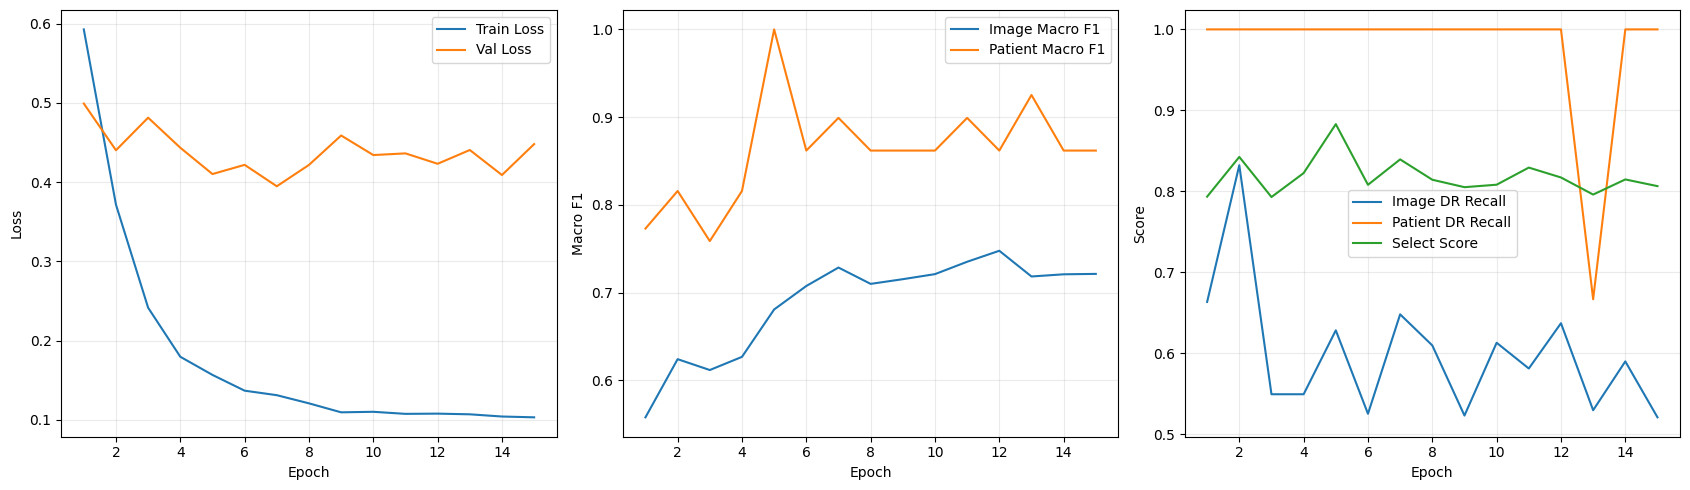

In [9]:
hist = pd.DataFrame(history)
plt.figure(figsize=(17, 5))

plt.subplot(1, 3, 1)
plt.plot(hist['epoch'], hist['train_loss'], label='Train Loss')
plt.plot(hist['epoch'], hist['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.25)

plt.subplot(1, 3, 2)
plt.plot(hist['epoch'], hist['img_macro_f1'], label='Image Macro F1')
plt.plot(hist['epoch'], hist['patient_macro_f1'], label='Patient Macro F1')
plt.xlabel('Epoch')
plt.ylabel('Macro F1')
plt.legend()
plt.grid(alpha=0.25)

plt.subplot(1, 3, 3)
plt.plot(hist['epoch'], hist['img_dr_recall'], label='Image DR Recall')
plt.plot(hist['epoch'], hist['patient_dr_recall'], label='Patient DR Recall')
plt.plot(hist['epoch'], hist['select_score'], label='Select Score')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(SAVE_DIR / 'training_curves_effb3_advanced.png', dpi=200)
plt.show()


In [10]:
ckpt = torch.load(CHECKPOINT, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
img_thr = ckpt['image_thresholds']
patient_thr = ckpt['patient_thresholds']

test_loss, test_probs, test_y, test_paths, test_pids = predict_loader(
    test_loader,
    'test',
    eval_model=model,
)

pred_argmax = test_probs.argmax(axis=1)
pred_thr = predict_with_thresholds(test_probs, img_thr['dr_thr'], img_thr['amd_thr'])

print('Best epoch:', ckpt['epoch'])
print('Best image thresholds:', img_thr)
print('Best patient thresholds:', patient_thr)
print('Test loss:', test_loss)

print('\nIMAGE-LEVEL RAPOR | ARGMAX')
print(classification_report(test_y, pred_argmax, target_names=CLASS_NAMES, digits=4, zero_division=0))
print('Balanced Accuracy:', balanced_accuracy_score(test_y, pred_argmax))
print('Macro AUC OvR:', safe_auc_ovr(test_y, test_probs, verbose=True))

print('\nIMAGE-LEVEL RAPOR | THRESHOLD')
print(classification_report(test_y, pred_thr, target_names=CLASS_NAMES, digits=4, zero_division=0))
print('Balanced Accuracy:', balanced_accuracy_score(test_y, pred_thr))
print('Macro AUC OvR:', safe_auc_ovr(test_y, test_probs, verbose=True))

pred_df = build_prediction_frame(test_probs, test_y, test_paths, test_pids)
pred_df['pred_argmax'] = pred_argmax
pred_df['pred_threshold'] = pred_thr
pred_df['pred_argmax_name'] = pred_df['pred_argmax'].map(IDX_TO_CLASS)
pred_df['pred_threshold_name'] = pred_df['pred_threshold'].map(IDX_TO_CLASS)

pred_df.to_csv(SAVE_DIR / 'test_image_predictions_effb3_advanced.csv', index=False)
print('Image prediction CSV kaydedildi.')


test:   0%|          | 0/722 [00:00<?, ?it/s]

/tmp/ipykernel_440/1929428434.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):


Best epoch: 5
Best image thresholds: {'dr_thr': 0.15, 'amd_thr': 0.15, 'macro_f1': 0.6807299098781918, 'balanced_acc': 0.6876644736842105, 'dr_recall': 0.6282894736842105, 'dr_precision': 0.7022058823529411, 'amd_recall': 0.5032894736842105, 'score': 0.6655977672189769}
Best patient thresholds: {'dr_thr': 0.44999999999999996, 'amd_thr': 0.625, 'macro_f1': 1.0, 'balanced_acc': 1.0, 'dr_recall': 1.0, 'dr_precision': 1.0, 'amd_recall': 1.0, 'score': 0.9999999999999999, 'mode': 'top40'}
Test loss: 0.24279419297398872

IMAGE-LEVEL RAPOR | ARGMAX
              precision    recall  f1-score   support

      NORMAL     0.9461    0.9972    0.9710      9424
          DR     0.9804    0.7127    0.8254      1824
         AMD     1.0000    0.9638    0.9816       304

    accuracy                         0.9514     11552
   macro avg     0.9755    0.8913    0.9260     11552
weighted avg     0.9530    0.9514    0.9483     11552

Balanced Accuracy: 0.8912587247689115
AUC hesaplanamadi: ValueError('Tar

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


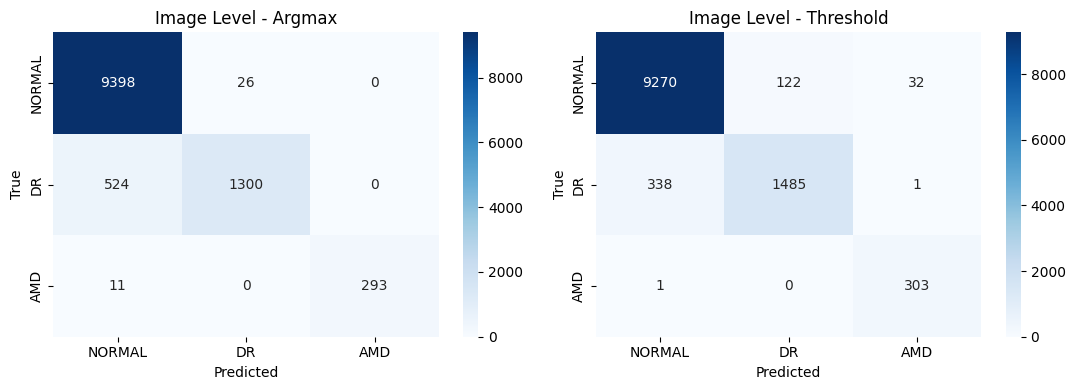

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


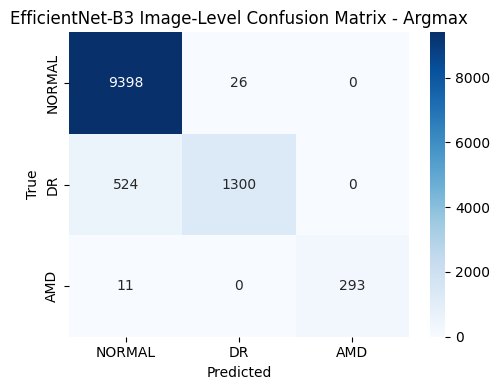

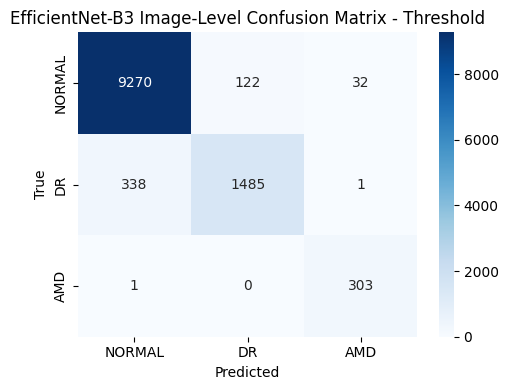

Image-level confusion matrix dosyalari kaydedildi.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [11]:
# -- HUCRE 12: Image-level confusion matrices | argmax + threshold ---
cm_img_argmax = confusion_matrix(test_y, pred_argmax)
cm_img_threshold = confusion_matrix(test_y, pred_thr)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(cm_img_argmax, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Image Level - Argmax')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(cm_img_threshold, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title('Image Level - Threshold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig(SAVE_DIR / 'confusion_matrix_image_effb3_advanced_argmax_threshold.png', dpi=200)
plt.show()

plt.figure(figsize=(5, 4))
sns.heatmap(cm_img_argmax, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('EfficientNet-B3 Image-Level Confusion Matrix - Argmax')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'confusion_matrix_image_effb3_advanced_argmax.png', dpi=200)
plt.show()

plt.figure(figsize=(5, 4))
sns.heatmap(cm_img_threshold, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('EfficientNet-B3 Image-Level Confusion Matrix - Threshold')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'confusion_matrix_image_effb3_advanced_threshold.png', dpi=200)
plt.show()

# Backward-compatible alias for older report code/file names.
cm = cm_img_threshold
plt.figure(figsize=(5, 4))
sns.heatmap(cm_img_threshold, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('EfficientNet-B3 Image-Level Confusion Matrix - Threshold')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'confusion_matrix_image_effb3_advanced.png', dpi=200)
plt.close()
print('Image-level confusion matrix dosyalari kaydedildi.')


Patient-level config: {'dr_thr': 0.44999999999999996, 'amd_thr': 0.625, 'macro_f1': 1.0, 'balanced_acc': 1.0, 'dr_recall': 1.0, 'dr_precision': 1.0, 'amd_recall': 1.0, 'score': 0.9999999999999999, 'mode': 'top40'}

PATIENT-LEVEL RAPOR | ARGMAX
              precision    recall  f1-score   support

      NORMAL     0.9688    1.0000    0.9841        31
          DR     1.0000    0.8333    0.9091         6
         AMD     1.0000    1.0000    1.0000         1

    accuracy                         0.9737        38
   macro avg     0.9896    0.9444    0.9644        38
weighted avg     0.9745    0.9737    0.9727        38

Patient Balanced Accuracy: 0.9444444444444445
AUC hesaplanamadi: ValueError('Target scores need to be probabilities for multiclass roc_auc, i.e. they should sum up to 1.0 over classes')
Patient Macro AUC OvR: nan

PATIENT-LEVEL RAPOR | THRESHOLD
              precision    recall  f1-score   support

      NORMAL     0.9677    0.9677    0.9677        31
          DR     0.8

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


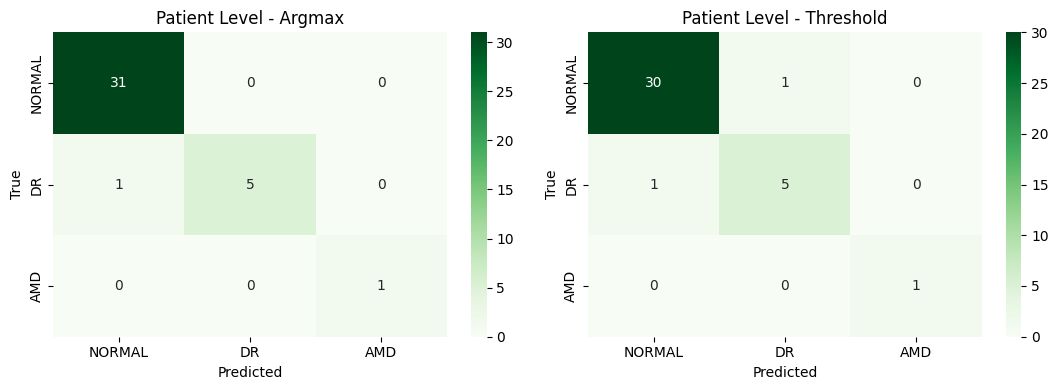

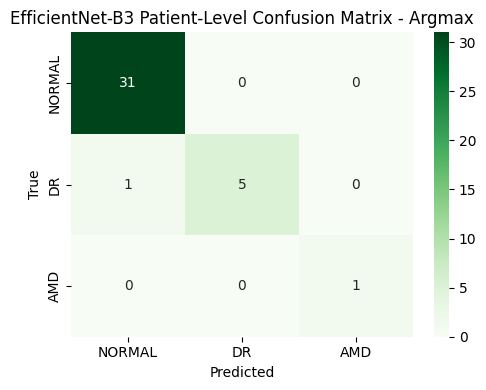

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


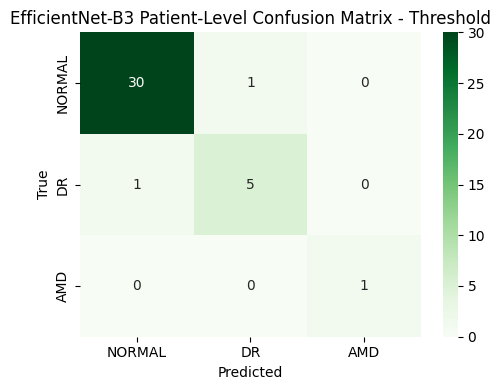

Patient-level dosyalari kaydedildi.


In [12]:
# -- HUCRE 13: Patient-level degerlendirme + confusion matrices ------
test_patient = patient_aggregate(pred_df, patient_thr['mode'])
test_patient_probs = test_patient[['p_normal', 'p_dr', 'p_amd']].values
test_patient['pred_argmax'] = test_patient_probs.argmax(axis=1)
test_patient['pred_threshold'] = predict_with_thresholds(test_patient_probs, patient_thr['dr_thr'], patient_thr['amd_thr'])
test_patient['pred_argmax_name'] = test_patient['pred_argmax'].map(IDX_TO_CLASS)
test_patient['pred_threshold_name'] = test_patient['pred_threshold'].map(IDX_TO_CLASS)

# Backward-compatible columns for report code.
test_patient['pred'] = test_patient['pred_threshold']
test_patient['pred_name'] = test_patient['pred_threshold_name']

print('Patient-level config:', patient_thr)
print('\nPATIENT-LEVEL RAPOR | ARGMAX')
print(classification_report(test_patient['true'], test_patient['pred_argmax'], target_names=CLASS_NAMES, digits=4, zero_division=0))
print('Patient Balanced Accuracy:', balanced_accuracy_score(test_patient['true'], test_patient['pred_argmax']))
print('Patient Macro AUC OvR:', safe_auc_ovr(test_patient['true'], test_patient_probs, verbose=True))

print('\nPATIENT-LEVEL RAPOR | THRESHOLD')
print(classification_report(test_patient['true'], test_patient['pred_threshold'], target_names=CLASS_NAMES, digits=4, zero_division=0))
print('Patient Balanced Accuracy:', balanced_accuracy_score(test_patient['true'], test_patient['pred_threshold']))
print('Patient Macro AUC OvR:', safe_auc_ovr(test_patient['true'], test_patient_probs, verbose=True))

cm_patient_argmax = confusion_matrix(test_patient['true'], test_patient['pred_argmax'])
cm_patient_threshold = confusion_matrix(test_patient['true'], test_patient['pred_threshold'])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(cm_patient_argmax, annot=True, fmt='d', cmap='Greens', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Patient Level - Argmax')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(cm_patient_threshold, annot=True, fmt='d', cmap='Greens', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title('Patient Level - Threshold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig(SAVE_DIR / 'confusion_matrix_patient_effb3_advanced_argmax_threshold.png', dpi=200)
plt.show()

plt.figure(figsize=(5, 4))
sns.heatmap(cm_patient_argmax, annot=True, fmt='d', cmap='Greens', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('EfficientNet-B3 Patient-Level Confusion Matrix - Argmax')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'confusion_matrix_patient_effb3_advanced_argmax.png', dpi=200)
plt.show()

plt.figure(figsize=(5, 4))
sns.heatmap(cm_patient_threshold, annot=True, fmt='d', cmap='Greens', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('EfficientNet-B3 Patient-Level Confusion Matrix - Threshold')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'confusion_matrix_patient_effb3_advanced_threshold.png', dpi=200)
plt.show()

# Backward-compatible alias for older report code/file names.
cm_patient = cm_patient_threshold

test_patient.to_csv(SAVE_DIR / 'test_patient_predictions_effb3_advanced.csv', index=False)
with open(SAVE_DIR / 'best_patient_threshold_effb3_advanced.json', 'w', encoding='utf-8') as f:
    json.dump(patient_thr, f, indent=2)

print('Patient-level dosyalari kaydedildi.')


In [13]:
# -- FINAL HUCRE: Metrik ozeti ve rapor dosyasi ----------------------
def metric_row(y_true, y_pred, probs, level, decision):
    row = {
        'level': level,
        'decision': decision,
        'accuracy': float((np.asarray(y_true) == np.asarray(y_pred)).mean()),
        'balanced_accuracy': float(balanced_accuracy_score(y_true, y_pred)),
        'macro_precision': float(precision_score(y_true, y_pred, average='macro', zero_division=0)),
        'macro_recall': float(recall_score(y_true, y_pred, average='macro', zero_division=0)),
        'macro_f1': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
        'macro_auc_ovr': float(safe_auc_ovr(y_true, probs, verbose=False)),
    }
    for idx, name in enumerate(CLASS_NAMES):
        key = name.lower()
        row[f'{key}_recall'] = float(recall_score(y_true, y_pred, labels=[idx], average='macro', zero_division=0))
        row[f'{key}_f1'] = float(f1_score(y_true, y_pred, labels=[idx], average='macro', zero_division=0))
    return row


metrics_summary = pd.DataFrame([
    metric_row(test_y, pred_argmax, test_probs, 'image', 'argmax'),
    metric_row(test_y, pred_thr, test_probs, 'image', 'threshold'),
    metric_row(test_patient['true'].values, test_patient['pred_argmax'].values, test_patient_probs, 'patient', f"{patient_thr['mode']}_argmax"),
    metric_row(test_patient['true'].values, test_patient['pred_threshold'].values, test_patient_probs, 'patient', f"{patient_thr['mode']}_threshold"),
])

preferred_cols = [
    'level', 'decision', 'accuracy', 'balanced_accuracy', 'macro_precision',
    'macro_recall', 'macro_f1', 'macro_auc_ovr',
    'normal_recall', 'dr_recall', 'amd_recall',
    'normal_f1', 'dr_f1', 'amd_f1',
]
metrics_summary = metrics_summary[[c for c in preferred_cols if c in metrics_summary.columns]]

metrics_path = SAVE_DIR / 'metrics_summary_effb3_advanced.csv'
report_path = SAVE_DIR / 'test_report_effb3_advanced.txt'
metrics_summary.to_csv(metrics_path, index=False)

with open(report_path, 'w', encoding='utf-8') as f:
    f.write('EfficientNet-B3 Advanced | OCT 3-Sinif | Final Colab\n')
    f.write('=' * 78 + '\n\n')
    f.write(f'Best epoch: {ckpt["epoch"]}\n')
    f.write(f'Image thresholds: {img_thr}\n')
    f.write(f'Patient thresholds: {patient_thr}\n\n')

    f.write('IMAGE-LEVEL RAPOR | ARGMAX\n')
    f.write(classification_report(test_y, pred_argmax, target_names=CLASS_NAMES, digits=4, zero_division=0))
    f.write(f'\nBalanced Accuracy: {balanced_accuracy_score(test_y, pred_argmax):.4f}\n')
    f.write(f'Macro AUC OvR: {safe_auc_ovr(test_y, test_probs, verbose=False):.4f}\n\n')

    f.write('IMAGE-LEVEL RAPOR | THRESHOLD\n')
    f.write(classification_report(test_y, pred_thr, target_names=CLASS_NAMES, digits=4, zero_division=0))
    f.write(f'\nBalanced Accuracy: {balanced_accuracy_score(test_y, pred_thr):.4f}\n')
    f.write(f'Macro AUC OvR: {safe_auc_ovr(test_y, test_probs, verbose=False):.4f}\n\n')

    f.write('PATIENT-LEVEL RAPOR\n')
    f.write(classification_report(test_patient['true'], test_patient['pred'], target_names=CLASS_NAMES, digits=4, zero_division=0))
    f.write(f'\nPatient Balanced Accuracy: {balanced_accuracy_score(test_patient["true"], test_patient["pred"]):.4f}\n')
    f.write(f'Patient Macro AUC OvR: {safe_auc_ovr(test_patient["true"], test_patient_probs, verbose=False):.4f}\n\n')
    f.write('IMAGE CM | THRESHOLD\n')
    f.write(np.array2string(cm) + '\n\n')
    f.write('PATIENT CM\n')
    f.write(np.array2string(cm_patient) + '\n')

summary = {
    'notebook': 'efficientnet_b3_advanced_oct_3sinif_colab',
    'checkpoint': str(CHECKPOINT),
    'history': str(HISTORY_PATH),
    'metrics_summary': str(metrics_path),
    'test_report': str(report_path),
    'image_predictions': str(SAVE_DIR / 'test_image_predictions_effb3_advanced.csv'),
    'patient_predictions': str(SAVE_DIR / 'test_patient_predictions_effb3_advanced.csv'),
}

print('Metrik tablosu kaydedildi:', metrics_path)
print('Rapor kaydedildi:', report_path)
display(metrics_summary.round(4))
summary


Metrik tablosu kaydedildi: /content/drive/MyDrive/bitirme/outputs/efficientnet_b3_advanced_oct_3sinif_colab/metrics_summary_effb3_advanced.csv
Rapor kaydedildi: /content/drive/MyDrive/bitirme/outputs/efficientnet_b3_advanced_oct_3sinif_colab/test_report_effb3_advanced.txt


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,level,decision,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,macro_auc_ovr,normal_recall,dr_recall,amd_recall,normal_f1,dr_f1,amd_f1
0,image,argmax,0.9514,0.8913,0.9755,0.8913,0.9260,NaN,0.9972,0.7127,0.9638,0.9710,0.8254,0.9816
1,image,threshold,0.9572,0.9315,0.9302,0.9315,0.9289,NaN,0.9837,0.8141,0.9967,0.9741,0.8656,0.9469
2,patient,top40_argmax,0.9737,0.9444,0.9896,0.9444,0.9644,NaN,1.0000,0.8333,1.0000,0.9841,0.9091,1.0000
3,patient,top40_threshold,0.9474,0.9337,0.9337,0.9337,0.9337,NaN,0.9677,0.8333,1.0000,0.9677,0.8333,1.0000


{'notebook': 'efficientnet_b3_advanced_oct_3sinif_colab',
 'checkpoint': '/content/drive/MyDrive/bitirme/outputs/efficientnet_b3_advanced_oct_3sinif_colab/efficientnet_b3_advanced_best_macrof1_patient.pt',
 'history': '/content/drive/MyDrive/bitirme/outputs/efficientnet_b3_advanced_oct_3sinif_colab/history_effb3_advanced.csv',
 'metrics_summary': '/content/drive/MyDrive/bitirme/outputs/efficientnet_b3_advanced_oct_3sinif_colab/metrics_summary_effb3_advanced.csv',
 'test_report': '/content/drive/MyDrive/bitirme/outputs/efficientnet_b3_advanced_oct_3sinif_colab/test_report_effb3_advanced.txt',
 'image_predictions': '/content/drive/MyDrive/bitirme/outputs/efficientnet_b3_advanced_oct_3sinif_colab/test_image_predictions_effb3_advanced.csv',
 'patient_predictions': '/content/drive/MyDrive/bitirme/outputs/efficientnet_b3_advanced_oct_3sinif_colab/test_patient_predictions_effb3_advanced.csv'}